# MSDS 604 Final Project — Ayush
## Approaches: SARIMAX & XGBoost

**Goal:** Forecast daily average ActivePower for 2020-03-16 to 2020-03-30 (15 days)

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
print(f"Raw shape: {df.shape}")
print(f"Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")
df.head()

Raw shape: (77202, 20)
Date range: 2018-01-01 06:20:00+00:00 to 2020-03-15 23:50:00+00:00


,Datetime,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,GeneratorWinding1Temperature,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WindDirection,WindSpeed
0,2018-01-01 06:20:00+00:00,26.212347,28.696304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,252.00,3.976499,NaN,NaN,252.00,3.042750
1,2018-01-01 06:40:00+00:00,59.632658,29.052567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.00,11.091660,NaN,NaN,255.00,3.424814
2,2018-01-01 06:50:00+00:00,40.889650,28.984758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,264.75,4.234497,NaN,NaN,264.75,3.507172
3,2018-01-01 10:40:00+00:00,34.398111,30.282058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.75,5.347792,NaN,NaN,283.75,3.442212
4,2018-01-01 12:00:00+00:00,29.797653,29.333519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.00,6.022326,NaN,NaN,274.00,3.031363


---
## 2. Daily Aggregation & Cleaning

In [2]:
daily = df.set_index('Datetime').resample('D').agg({
    'ActivePower': 'mean',
    'AmbientTemperatue': 'mean',
    'WindSpeed': 'mean',
    'ReactivePower': 'mean',
    'WindDirection': 'mean'
})

print(f"Missing before interpolation:\n{daily.isnull().sum()}")
daily = daily.interpolate(method='linear')
daily = daily.dropna()
print(f"\nFinal daily shape: {daily.shape}")
print(f"Date range: {daily.index.min()} to {daily.index.max()}")

Missing before interpolation:
ActivePower          71
AmbientTemperatue    75
WindSpeed            72
ReactivePower        71
WindDirection        74
dtype: int64

Final daily shape: (805, 5)
Date range: 2018-01-01 00:00:00+00:00 to 2020-03-15 00:00:00+00:00


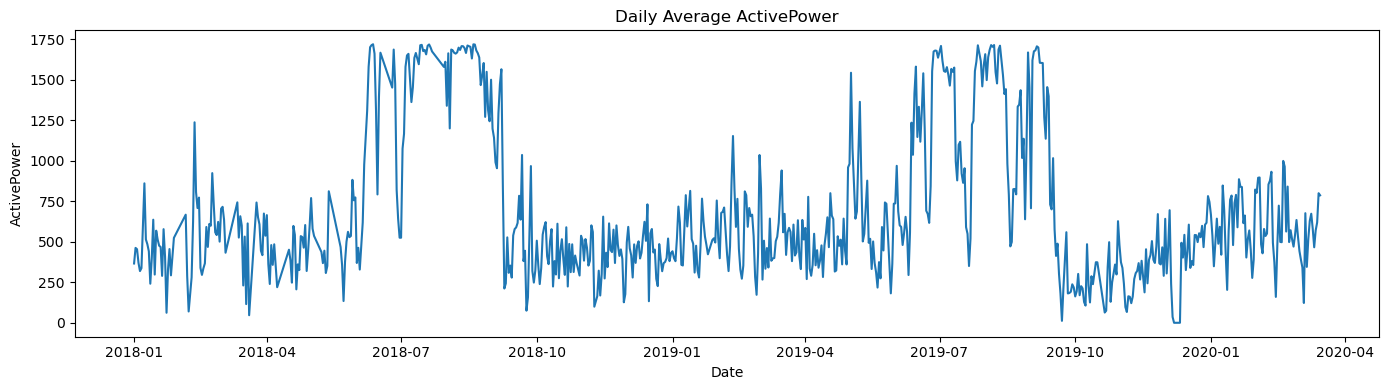

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['ActivePower'])
ax.set_title('Daily Average ActivePower')
ax.set_xlabel('Date')
ax.set_ylabel('ActivePower')
plt.tight_layout()
plt.show()

---
## 3. Train/Validation Split

In [4]:
val_days = 15
train = daily.iloc[:-val_days]
val = daily.iloc[-val_days:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} days)")
print(f"Val:   {val.index.min()} to {val.index.max()} ({len(val)} days)")

Train: 2018-01-01 00:00:00+00:00 to 2020-02-29 00:00:00+00:00 (790 days)
Val:   2020-03-01 00:00:00+00:00 to 2020-03-15 00:00:00+00:00 (15 days)


In [5]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

---
## 4. Approach 1: SARIMAX

### 4.1 Stationarity Check

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['ActivePower'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("=> Series is stationary (d=0)")
else:
    print("=> Series is non-stationary (d=1)")

ADF Statistic: -3.2063
p-value: 0.0196
=> Series is stationary (d=0)


### 4.2 ACF / PACF Plots

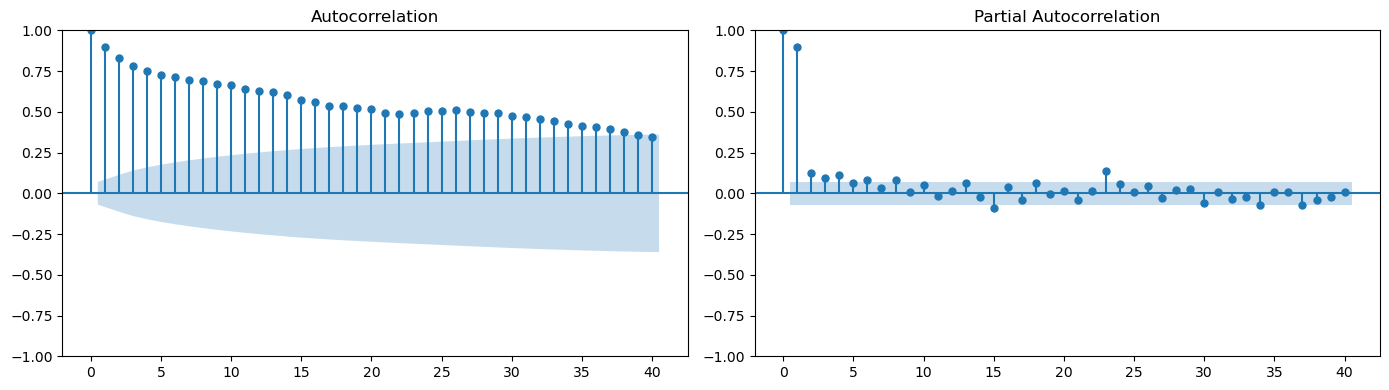

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train['ActivePower'], lags=40, ax=axes[0])
plot_pacf(train['ActivePower'], lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

### 4.3 SARIMAX — Manual Grid Search (with exog, s=7)

Brute-force search over (p,d,q)(P,D,Q,7) with exogenous variables.

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

exog_cols = ['WindSpeed', 'AmbientTemperatue']
train_exog = train[exog_cols]
val_exog = val[exog_cols]

# Grid search space
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
P_range = range(0, 2)
D_range = range(0, 2)
Q_range = range(0, 2)
s = 7

best_aic = np.inf
best_order = None
best_seasonal = None
grid_results = []

total = len(list(product(p_range, d_range, q_range, P_range, D_range, Q_range)))
print(f"Testing {total} combinations...")

count = 0
for p, d, q, P, D, Q in product(p_range, d_range, q_range, P_range, D_range, Q_range):
    count += 1
    try:
        model = SARIMAX(
            train['ActivePower'],
            exog=train_exog,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False, maxiter=200)
        grid_results.append(((p,d,q), (P,D,Q,s), fit.aic))
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = (p, d, q)
            best_seasonal = (P, D, Q, s)
            print(f"  [{count}/{total}] New best: ({p},{d},{q})({P},{D},{Q},{s}) AIC={fit.aic:.2f}")
    except:
        continue

print(f"\nGrid search best order: {best_order}")
print(f"Grid search best seasonal: {best_seasonal}")
print(f"Grid search best AIC: {best_aic:.2f}")

Testing 144 combinations...
  [1/144] New best: (0,0,0)(0,0,0,7) AIC=10076.72
  [2/144] New best: (0,0,0)(0,0,1,7) AIC=9886.68
  [4/144] New best: (0,0,0)(0,1,1,7) AIC=9414.56
  [12/144] New best: (0,0,1)(0,1,1,7) AIC=9107.48
  [16/144] New best: (0,0,1)(1,1,1,7) AIC=9106.67
  [20/144] New best: (0,0,2)(0,1,1,7) AIC=9017.99
  [24/144] New best: (0,0,2)(1,1,1,7) AIC=9015.08
  [52/144] New best: (1,0,0)(0,1,1,7) AIC=8987.71
  [56/144] New best: (1,0,0)(1,1,1,7) AIC=8983.04
  [60/144] New best: (1,0,1)(0,1,1,7) AIC=8979.29
  [64/144] New best: (1,0,1)(1,1,1,7) AIC=8974.32
  [68/144] New best: (1,0,2)(0,1,1,7) AIC=8970.76
  [72/144] New best: (1,0,2)(1,1,1,7) AIC=8965.55

Grid search best order: (1, 0, 2)
Grid search best seasonal: (1, 1, 1, 7)
Grid search best AIC: 8965.55


### 4.3b SARIMAX — auto_arima Configs

Also run auto_arima with different settings in case it finds something the grid missed.

In [9]:
import pmdarima as pm

sarimax_results = {}

# Store grid search result
sarimax_results['grid_exog_s7'] = {
    'order': best_order, 'seasonal': best_seasonal, 'aic': best_aic
}

# --- auto_arima: exog, s=7, force seasonal search ---
print("=== auto_arima: exog, s=7, non-stepwise ===")
auto1 = pm.auto_arima(
    train['ActivePower'], exogenous=train_exog,
    seasonal=True, m=7, stepwise=False,
    start_P=0, max_P=2, start_Q=0, max_Q=2, D=None,
    suppress_warnings=True, trace=True, n_jobs=-1
)
pred1 = auto1.predict(n_periods=val_days, exogenous=val_exog)
rmse1 = rmse(val['ActivePower'], pred1)
sarimax_results['auto_exog_s7'] = {
    'model': auto1, 'rmse': rmse1,
    'order': auto1.order, 'seasonal': auto1.seasonal_order
}
print(f"Order: {auto1.order}, Seasonal: {auto1.seasonal_order}, RMSE: {rmse1:.2f}\n")

=== auto_arima: exog, s=7, non-stepwise ===
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=11952.136, Time=0.01 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=11673.798, Time=0.12 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=11221.716, Time=0.24 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=11351.864, Time=0.08 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=11434.579, Time=0.25 sec
 ARIMA(0,0,0)(0,0,2)[7] intercept   : AIC=11500.724, Time=0.35 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=11093.144, Time=0.26 sec
 ARIMA(0,0,1)(0,0,2)[7] intercept   : AIC=11103.485, Time=0.44 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=11018.520, Time=0.50 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,0,0)(2,0,0)[7] intercept   : AIC=11392.450, Time=0.76 sec
 ARIMA(0,0,2)(0,0,0)[7] intercept   : AIC=11062.337, Time=0.09 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=11411.470, Time=1.01 sec
 ARIMA(0,0,2)(0,0,1)[7] interc

In [10]:
# --- auto_arima: no exog, s=7, non-stepwise ---
print("=== auto_arima: no exog, s=7, non-stepwise ===")
auto2 = pm.auto_arima(
    train['ActivePower'],
    seasonal=True, m=7, stepwise=False,
    start_P=0, max_P=2, start_Q=0, max_Q=2, D=None,
    suppress_warnings=True, trace=True, n_jobs=-1
)
pred2 = auto2.predict(n_periods=val_days)
rmse2 = rmse(val['ActivePower'], pred2)
sarimax_results['auto_no_exog_s7'] = {
    'model': auto2, 'rmse': rmse2,
    'order': auto2.order, 'seasonal': auto2.seasonal_order
}
print(f"Order: {auto2.order}, Seasonal: {auto2.seasonal_order}, RMSE: {rmse2:.2f}\n")

=== auto_arima: no exog, s=7, non-stepwise ===
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=11952.136, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=11351.864, Time=0.06 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=11673.798, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=11221.716, Time=0.15 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=11434.579, Time=0.20 sec
 ARIMA(0,0,0)(0,0,2)[7] intercept   : AIC=11500.724, Time=0.30 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=11093.144, Time=0.31 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(0,0,1)(0,0,2)[7] intercept   : AIC=11103.485, Time=0.44 sec
 ARIMA(0,0,0)(2,0,0)[7] intercept   : AIC=11392.450, Time=0.68 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=11018.520, Time=0.49 sec
 ARIMA(0,0,2)(0,0,0)[7] intercept   : AIC=11062.337, Time=0.10 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=11411.470, Time=0.94 sec
 ARIMA(0,0,1)(1,0,2)[7] int

In [11]:
# --- auto_arima: exog, s=14, non-stepwise ---
print("=== auto_arima: exog, s=14, non-stepwise ===")
auto3 = pm.auto_arima(
    train['ActivePower'], exogenous=train_exog,
    seasonal=True, m=14, stepwise=False,
    start_P=0, max_P=2, start_Q=0, max_Q=2, D=None,
    suppress_warnings=True, trace=True, n_jobs=-1
)
pred3 = auto3.predict(n_periods=val_days, exogenous=val_exog)
rmse3 = rmse(val['ActivePower'], pred3)
sarimax_results['auto_exog_s14'] = {
    'model': auto3, 'rmse': rmse3,
    'order': auto3.order, 'seasonal': auto3.seasonal_order
}
print(f"Order: {auto3.order}, Seasonal: {auto3.seasonal_order}, RMSE: {rmse3:.2f}\n")

=== auto_arima: exog, s=14, non-stepwise ===
 ARIMA(0,0,0)(0,0,0)[14] intercept   : AIC=11952.136, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[14] intercept   : AIC=11351.864, Time=0.06 sec
 ARIMA(0,0,0)(0,0,1)[14] intercept   : AIC=11738.644, Time=0.21 sec
 ARIMA(0,0,1)(0,0,1)[14] intercept   : AIC=11205.129, Time=0.28 sec
 ARIMA(0,0,0)(1,0,0)[14] intercept   : AIC=11595.144, Time=0.36 sec
 ARIMA(0,0,0)(1,0,1)[14] intercept   : AIC=11574.972, Time=0.72 sec
 ARIMA(0,0,1)(1,0,0)[14] intercept   : AIC=11129.023, Time=0.56 sec
 ARIMA(0,0,0)(0,0,2)[14] intercept   : AIC=11628.052, Time=0.98 sec
 ARIMA(0,0,1)(1,0,1)[14] intercept   : AIC=11197.608, Time=0.55 sec
 ARIMA(0,0,1)(0,0,2)[14] intercept   : AIC=11145.769, Time=1.30 sec
 ARIMA(0,0,2)(0,0,0)[14] intercept   : AIC=11062.337, Time=0.11 sec
 ARIMA(0,0,0)(2,0,0)[14] intercept   : AIC=11563.883, Time=1.92 sec
 ARIMA(0,0,0)(2,0,1)[14] intercept   : AIC=inf, Time=2.05 sec
 ARIMA(0,0,2)(0,0,1)[14] intercept   : AIC=10978.951, Time=0.44 sec
 ARIMA(0,

In [12]:
# --- auto_arima: no exog, s=14, non-stepwise ---
print("=== auto_arima: no exog, s=14, non-stepwise ===")
auto4 = pm.auto_arima(
    train['ActivePower'],
    seasonal=True, m=14, stepwise=False,
    start_P=0, max_P=2, start_Q=0, max_Q=2, D=None,
    suppress_warnings=True, trace=True, n_jobs=-1
)
pred4 = auto4.predict(n_periods=val_days)
rmse4 = rmse(val['ActivePower'], pred4)
sarimax_results['auto_no_exog_s14'] = {
    'model': auto4, 'rmse': rmse4,
    'order': auto4.order, 'seasonal': auto4.seasonal_order
}
print(f"Order: {auto4.order}, Seasonal: {auto4.seasonal_order}, RMSE: {rmse4:.2f}\n")

=== auto_arima: no exog, s=14, non-stepwise ===
 ARIMA(0,0,0)(0,0,0)[14] intercept   : AIC=11952.136, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[14] intercept   : AIC=11351.864, Time=0.06 sec
 ARIMA(0,0,0)(0,0,1)[14] intercept   : AIC=11738.644, Time=0.21 sec
 ARIMA(0,0,1)(0,0,1)[14] intercept   : AIC=11205.129, Time=0.29 sec
 ARIMA(0,0,0)(1,0,0)[14] intercept   : AIC=11595.144, Time=0.38 sec
 ARIMA(0,0,0)(1,0,1)[14] intercept   : AIC=11574.972, Time=0.77 sec
 ARIMA(0,0,1)(1,0,0)[14] intercept   : AIC=11129.023, Time=0.60 sec
 ARIMA(0,0,0)(0,0,2)[14] intercept   : AIC=11628.052, Time=1.00 sec
 ARIMA(0,0,1)(1,0,1)[14] intercept   : AIC=11197.608, Time=0.59 sec
 ARIMA(0,0,1)(0,0,2)[14] intercept   : AIC=11145.769, Time=1.26 sec
 ARIMA(0,0,2)(0,0,0)[14] intercept   : AIC=11062.337, Time=0.09 sec
 ARIMA(0,0,0)(2,0,0)[14] intercept   : AIC=11563.883, Time=1.92 sec
 ARIMA(0,0,0)(2,0,1)[14] intercept   : AIC=inf, Time=2.03 sec
 ARIMA(0,0,2)(0,0,1)[14] intercept   : AIC=10978.951, Time=0.46 sec
 ARIMA

Exception ignored in: <function ResourceTracker.__del__ at 0x104fe4f40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


 ARIMA(0,0,2)(2,0,1)[14] intercept   : AIC=inf, Time=2.76 sec
 ARIMA(1,0,0)(2,0,1)[14] intercept   : AIC=10659.083, Time=2.32 sec
 ARIMA(0,0,3)(2,0,0)[14] intercept   : AIC=10839.077, Time=3.44 sec
 ARIMA(1,0,0)(2,0,2)[14] intercept   : AIC=inf, Time=3.93 sec
 ARIMA(1,0,1)(0,0,0)[14] intercept   : AIC=10649.293, Time=0.10 sec
 ARIMA(1,0,2)(1,0,0)[14] intercept   : AIC=10633.858, Time=0.95 sec
 ARIMA(1,0,1)(1,0,2)[14] intercept   : AIC=10647.123, Time=2.87 sec
 ARIMA(1,0,2)(1,0,1)[14] intercept   : AIC=10637.215, Time=0.85 sec
 ARIMA(1,0,1)(2,0,1)[14] intercept   : AIC=10647.023, Time=2.81 sec
 ARIMA(1,0,3)(0,0,1)[14] intercept   : AIC=10626.893, Time=1.41 sec
 ARIMA(1,0,4)(0,0,0)[14] intercept   : AIC=10629.474, Time=0.35 sec
 ARIMA(1,0,2)(0,0,0)[14] intercept   : AIC=10638.060, Time=0.12 sec
 ARIMA(1,0,3)(1,0,0)[14] intercept   : AIC=10626.771, Time=1.13 sec
 ARIMA(2,0,0)(0,0,0)[14] intercept   : AIC=10653.174, Time=0.02 sec
 ARIMA(1,0,2)(0,0,1)[14] intercept   : AIC=10634.063, Time=0

### 4.4 Validate Grid Search Model & Compare All

In [13]:
# Validate the grid search model (not yet validated)
grid_model = SARIMAX(
    train['ActivePower'],
    exog=train_exog,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

grid_val_pred = grid_model.forecast(steps=val_days, exog=val_exog)
grid_val_rmse = rmse(val['ActivePower'], grid_val_pred)
sarimax_results['grid_exog_s7']['rmse'] = grid_val_rmse
sarimax_results['grid_exog_s7']['model'] = grid_model
print(f"Grid search model RMSE: {grid_val_rmse:.2f}")

# Also try grid search model WITHOUT exog
grid_model_no_exog = SARIMAX(
    train['ActivePower'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

grid_val_pred_no_exog = grid_model_no_exog.forecast(steps=val_days)
grid_val_rmse_no_exog = rmse(val['ActivePower'], grid_val_pred_no_exog)
sarimax_results['grid_no_exog_s7'] = {
    'rmse': grid_val_rmse_no_exog, 'model': grid_model_no_exog,
    'order': best_order, 'seasonal': best_seasonal
}
print(f"Grid search model (no exog) RMSE: {grid_val_rmse_no_exog:.2f}")

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grid search model RMSE: 55.38
Grid search model (no exog) RMSE: 182.53


In [14]:
# --- Full comparison ---
print("\n=== SARIMAX Configuration Comparison ===")
for name, res in sorted(sarimax_results.items(), key=lambda x: x[1]['rmse']):
    order_str = str(res.get('order', 'N/A'))
    seasonal_str = str(res.get('seasonal', 'N/A'))
    print(f"{name:25s} | Order: {order_str:15s} | Seasonal: {seasonal_str:20s} | RMSE: {res['rmse']:.2f}")

best_sarimax_name = min(sarimax_results, key=lambda x: sarimax_results[x]['rmse'])
best_sarimax = sarimax_results[best_sarimax_name]
print(f"\nBest config: {best_sarimax_name} (RMSE: {best_sarimax['rmse']:.2f})")


=== SARIMAX Configuration Comparison ===
grid_exog_s7              | Order: (1, 0, 2)       | Seasonal: (1, 1, 1, 7)         | RMSE: 55.38
auto_exog_s7              | Order: (2, 0, 1)       | Seasonal: (0, 0, 0, 7)         | RMSE: 178.81
auto_no_exog_s7           | Order: (2, 0, 1)       | Seasonal: (0, 0, 0, 7)         | RMSE: 178.81
grid_no_exog_s7           | Order: (1, 0, 2)       | Seasonal: (1, 1, 1, 7)         | RMSE: 182.53
auto_exog_s14             | Order: (2, 0, 1)       | Seasonal: (0, 0, 1, 14)        | RMSE: 185.38
auto_no_exog_s14          | Order: (2, 0, 1)       | Seasonal: (0, 0, 1, 14)        | RMSE: 185.38

Best config: grid_exog_s7 (RMSE: 55.38)


Best SARIMAX Validation RMSE: 55.38


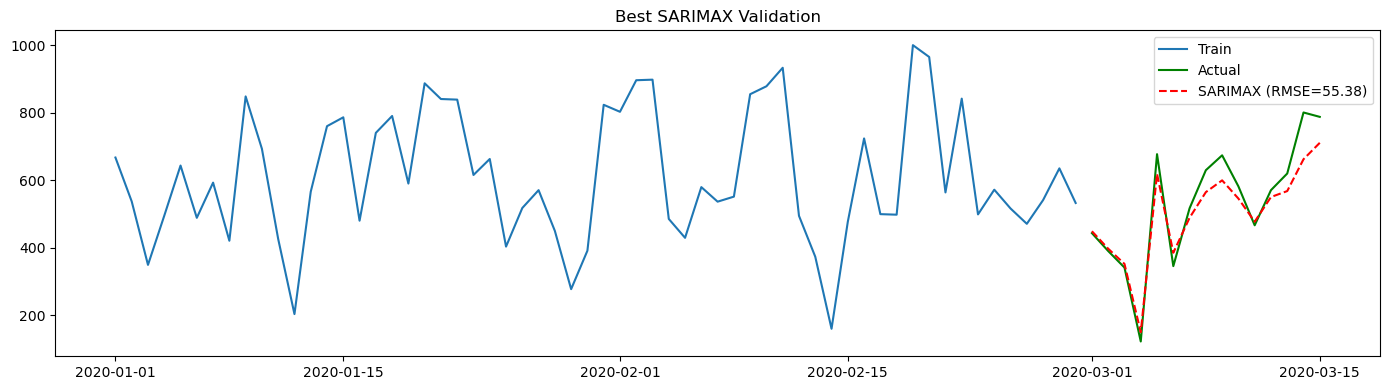

In [16]:
# Determine if best uses exog
uses_exog = 'no_exog' not in best_sarimax_name
best_sarimax_model_obj = best_sarimax['model']

# Check if it's a pmdarima model or statsmodels model
is_pmdarima = hasattr(best_sarimax_model_obj, 'arima_res_')

if is_pmdarima:
    if uses_exog:
        sarimax_val_pred = best_sarimax_model_obj.predict(n_periods=val_days, exogenous=val_exog)
    else:
        sarimax_val_pred = best_sarimax_model_obj.predict(n_periods=val_days)
else:
    if uses_exog:
        sarimax_val_pred = best_sarimax_model_obj.forecast(steps=val_days, exog=val_exog)
    else:
        sarimax_val_pred = best_sarimax_model_obj.forecast(steps=val_days)

sarimax_val_rmse = rmse(val['ActivePower'], sarimax_val_pred)
print(f"Best SARIMAX Validation RMSE: {sarimax_val_rmse:.2f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index[-60:], train['ActivePower'].iloc[-60:], label='Train')
ax.plot(val.index, val['ActivePower'], label='Actual', color='green')
ax.plot(val.index, sarimax_val_pred, label=f'SARIMAX (RMSE={sarimax_val_rmse:.2f})', color='red', linestyle='--')
ax.legend()
ax.set_title('Best SARIMAX Validation')
plt.tight_layout()
plt.show()

### 4.5 SARIMAX — Final Forecast

In [17]:
final_order = best_sarimax['order']
final_seasonal = best_sarimax['seasonal']

if uses_exog:
    sarimax_final = SARIMAX(
        daily['ActivePower'], exog=daily[exog_cols],
        order=final_order, seasonal_order=final_seasonal,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    future_exog = pd.DataFrame({
        col: [daily[col].iloc[-15:].mean()] * 15 for col in exog_cols
    }, index=pd.date_range('2020-03-16', periods=15, freq='D', tz='UTC'))
    sarimax_forecast = sarimax_final.forecast(steps=15, exog=future_exog)
else:
    sarimax_final = SARIMAX(
        daily['ActivePower'],
        order=final_order, seasonal_order=final_seasonal,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    sarimax_forecast = sarimax_final.forecast(steps=15)

sarimax_forecast = sarimax_forecast.clip(lower=0)
print("SARIMAX 15-day Forecast:")
print(sarimax_forecast)

SARIMAX 15-day Forecast:
2020-03-16 00:00:00+00:00    537.786526
2020-03-17 00:00:00+00:00    536.801435
2020-03-18 00:00:00+00:00    538.289668
2020-03-19 00:00:00+00:00    526.016250
2020-03-20 00:00:00+00:00    515.506993
2020-03-21 00:00:00+00:00    492.972041
2020-03-22 00:00:00+00:00    488.954012
2020-03-23 00:00:00+00:00    489.338243
2020-03-24 00:00:00+00:00    501.658594
2020-03-25 00:00:00+00:00    510.465319
2020-03-26 00:00:00+00:00    509.487241
2020-03-27 00:00:00+00:00    507.862052
2020-03-28 00:00:00+00:00    497.889590
2020-03-29 00:00:00+00:00    490.543976
2020-03-30 00:00:00+00:00    490.008412
Freq: D, Name: predicted_mean, dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---
## 5. Approach 2: XGBoost 

### 5.1 Feature Engineering 

In [18]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

def create_features(data, target_col='ActivePower'):
    """Create lag, rolling, EWM, and calendar features."""
    df_feat = data.copy()
    df_feat.index = pd.to_datetime(df_feat.index)
    
    # --- Lag features (ActivePower) ---
    for lag in [1, 2, 3, 5, 7, 14, 21, 28]:
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)
    
    # --- Rolling window features ---
    for window in [3, 7, 14, 30]:
        df_feat[f'rolling_mean_{window}'] = df_feat[target_col].shift(1).rolling(window).mean()
        df_feat[f'rolling_std_{window}'] = df_feat[target_col].shift(1).rolling(window).std()
        df_feat[f'rolling_min_{window}'] = df_feat[target_col].shift(1).rolling(window).min()
        df_feat[f'rolling_max_{window}'] = df_feat[target_col].shift(1).rolling(window).max()
    
    # --- Exponentially weighted moving average ---
    for span in [7, 14, 30]:
        df_feat[f'ewm_{span}'] = df_feat[target_col].shift(1).ewm(span=span).mean()
    
    # --- WindSpeed lag features ---
    for lag in [1, 2, 3, 7]:
        df_feat[f'wind_lag_{lag}'] = df_feat['WindSpeed'].shift(lag)
    
    # --- WindSpeed rolling features ---
    for window in [3, 7, 14]:
        df_feat[f'wind_rolling_mean_{window}'] = df_feat['WindSpeed'].shift(1).rolling(window).mean()
    
    # --- Calendar features ---
    df_feat['day_of_week'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['day_of_year'] = df_feat.index.dayofyear
    
    # --- Diff features (momentum) ---
    df_feat['diff_1'] = df_feat[target_col].diff(1)
    df_feat['diff_7'] = df_feat[target_col].diff(7)
    
    return df_feat

daily_feat = create_features(daily)
daily_feat = daily_feat.dropna()
print(f"Feature matrix shape: {daily_feat.shape}")
print(f"Features: {[c for c in daily_feat.columns if c != 'ActivePower']}")

Feature matrix shape: (775, 44)
Features: ['AmbientTemperatue', 'WindSpeed', 'ReactivePower', 'WindDirection', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_min_30', 'rolling_max_30', 'ewm_7', 'ewm_14', 'ewm_30', 'wind_lag_1', 'wind_lag_2', 'wind_lag_3', 'wind_lag_7', 'wind_rolling_mean_3', 'wind_rolling_mean_7', 'wind_rolling_mean_14', 'day_of_week', 'month', 'day_of_year', 'diff_1', 'diff_7']


### 5.2 Train/Validation & Hyperparameter Tuning

In [19]:
feature_cols = [c for c in daily_feat.columns if c != 'ActivePower']
target_col = 'ActivePower'

train_xgb = daily_feat.iloc[:-val_days]
val_xgb = daily_feat.iloc[-val_days:]

X_train = train_xgb[feature_cols]
y_train = train_xgb[target_col]
X_val = val_xgb[feature_cols]
y_val = val_xgb[target_col]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

X_train: (760, 43), X_val: (15, 43)


In [20]:
param_grid = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
random_search = RandomizedSearchCV(
    xgb, param_grid, cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_iter=200, n_jobs=-1, verbose=1, random_state=42
)
random_search.fit(X_train, y_train)

print(f"\nBest params: {random_search.best_params_}")
print(f"Best CV RMSE: {-random_search.best_score_:.2f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Best params: {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV RMSE: 172.75


XGBoost Validation RMSE: 61.11


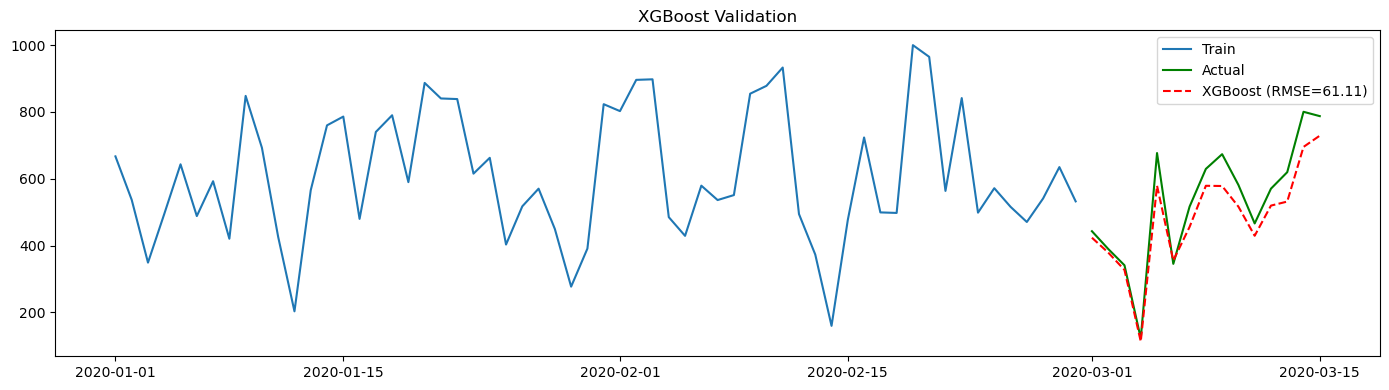

In [21]:
best_xgb = random_search.best_estimator_
xgb_val_pred = best_xgb.predict(X_val)
xgb_val_rmse = rmse(y_val, xgb_val_pred)
print(f"XGBoost Validation RMSE: {xgb_val_rmse:.2f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_xgb.index[-60:], train_xgb[target_col].iloc[-60:], label='Train')
ax.plot(val_xgb.index, y_val, label='Actual', color='green')
ax.plot(val_xgb.index, xgb_val_pred, label=f'XGBoost (RMSE={xgb_val_rmse:.2f})', color='red', linestyle='--')
ax.legend()
ax.set_title('XGBoost Validation')
plt.tight_layout()
plt.show()

### 5.3 Feature Importance

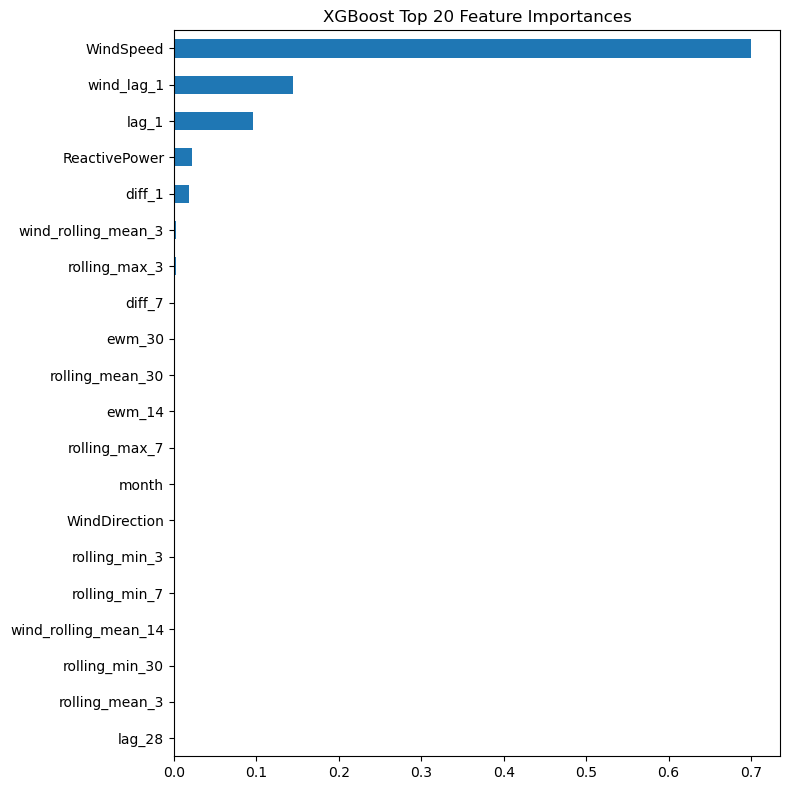

In [22]:
importance = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 8))
importance.tail(20).plot.barh(ax=ax)
ax.set_title('XGBoost Top 20 Feature Importances')
plt.tight_layout()
plt.show()

### 5.4 XGBoost — Final Forecast (Recursive)

In [23]:
X_full = daily_feat[feature_cols]
y_full = daily_feat[target_col]

final_xgb = XGBRegressor(**random_search.best_params_, random_state=42, objective='reg:squarederror')
final_xgb.fit(X_full, y_full)

forecast_dates = pd.date_range('2020-03-16', periods=15, freq='D', tz='UTC')
history = daily.copy()
xgb_preds = []

for date in forecast_dates:
    temp = create_features(history)
    last_row = temp.iloc[[-1]][feature_cols]
    
    for col in ['WindSpeed', 'AmbientTemperatue', 'ReactivePower', 'WindDirection']:
        if col in last_row.columns:
            last_row[col] = history[col].iloc[-15:].mean()
    
    last_row['day_of_week'] = date.dayofweek
    last_row['month'] = date.month
    last_row['day_of_year'] = date.dayofyear
    
    pred = final_xgb.predict(last_row)[0]
    pred = max(pred, 0)
    xgb_preds.append(pred)
    
    new_row = history.iloc[-1:].copy()
    new_row.index = [date]
    new_row['ActivePower'] = pred
    for col in ['WindSpeed', 'AmbientTemperatue', 'ReactivePower', 'WindDirection']:
        new_row[col] = history[col].iloc[-15:].mean()
    history = pd.concat([history, new_row])

xgb_forecast = pd.Series(xgb_preds, index=forecast_dates)
print("XGBoost 15-day Forecast:")
print(xgb_forecast)

XGBoost 15-day Forecast:
2020-03-16 00:00:00+00:00    530.173279
2020-03-17 00:00:00+00:00    475.933197
2020-03-18 00:00:00+00:00    515.768921
2020-03-19 00:00:00+00:00    513.209839
2020-03-20 00:00:00+00:00    518.903137
2020-03-21 00:00:00+00:00    505.694519
2020-03-22 00:00:00+00:00    541.704773
2020-03-23 00:00:00+00:00    546.231506
2020-03-24 00:00:00+00:00    548.725220
2020-03-25 00:00:00+00:00    542.151794
2020-03-26 00:00:00+00:00    537.849548
2020-03-27 00:00:00+00:00    551.992859
2020-03-28 00:00:00+00:00    562.272339
2020-03-29 00:00:00+00:00    563.218323
2020-03-30 00:00:00+00:00    539.914673
Freq: D, dtype: float32


---
## 6. Model Comparison & Ensemble

In [24]:
print("=== Validation RMSE Comparison ===")
print(f"SARIMAX ({best_sarimax_name}):  {sarimax_val_rmse:.2f}")
print(f"XGBoost:                        {xgb_val_rmse:.2f}")

# --- Ensemble: search weights on validation ---
print("\n=== Ensemble Weight Search (on validation) ===")
best_ensemble_rmse = np.inf
best_w = None

# Get SARIMAX val predictions
sarimax_val_preds_arr = np.array(sarimax_val_pred)
xgb_val_preds_arr = best_xgb.predict(X_val)

for w in np.arange(0.0, 1.05, 0.05):
    ensemble_val = w * sarimax_val_preds_arr + (1 - w) * xgb_val_preds_arr
    ens_rmse = rmse(val['ActivePower'], ensemble_val)
    if ens_rmse < best_ensemble_rmse:
        best_ensemble_rmse = ens_rmse
        best_w = w

print(f"Best ensemble weight: {best_w:.2f} SARIMAX + {1-best_w:.2f} XGBoost")
print(f"Best ensemble RMSE:   {best_ensemble_rmse:.2f}")

print(f"\n=== Summary ===")
all_rmses = {
    f'SARIMAX ({best_sarimax_name})': sarimax_val_rmse,
    'XGBoost': xgb_val_rmse,
    f'Ensemble ({best_w:.2f}/{1-best_w:.2f})': best_ensemble_rmse
}
for name, r in sorted(all_rmses.items(), key=lambda x: x[1]):
    print(f"  {name:40s}: {r:.2f}")

overall_best = min(all_rmses, key=all_rmses.get)
print(f"\nOverall best: {overall_best} (RMSE: {all_rmses[overall_best]:.2f})")

=== Validation RMSE Comparison ===
SARIMAX (grid_exog_s7):  55.38
XGBoost:                        61.11

=== Ensemble Weight Search (on validation) ===
Best ensemble weight: 0.85 SARIMAX + 0.15 XGBoost
Best ensemble RMSE:   55.22

=== Summary ===
  Ensemble (0.85/0.15)                    : 55.22
  SARIMAX (grid_exog_s7)                  : 55.38
  XGBoost                                 : 61.11

Overall best: Ensemble (0.85/0.15) (RMSE: 55.22)


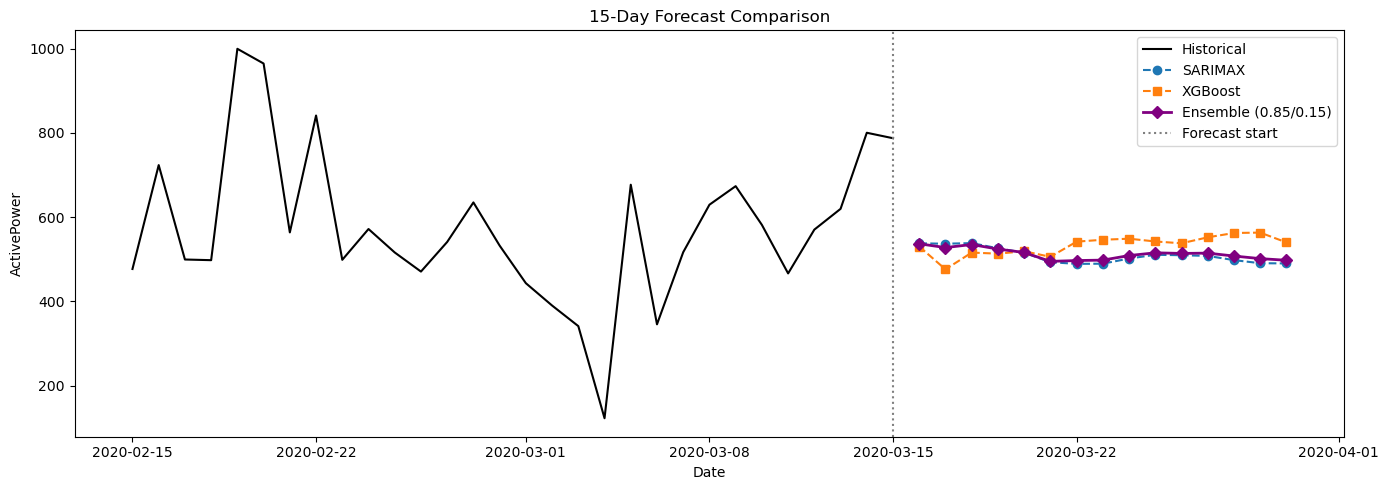

In [25]:
# Ensemble final forecast
ensemble_forecast = best_w * sarimax_forecast.values + (1 - best_w) * xgb_forecast.values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index[-30:], daily['ActivePower'].iloc[-30:], label='Historical', color='black')
ax.plot(sarimax_forecast.index, sarimax_forecast.values, label='SARIMAX', marker='o', linestyle='--')
ax.plot(xgb_forecast.index, xgb_forecast.values, label='XGBoost', marker='s', linestyle='--')
ax.plot(forecast_dates, ensemble_forecast, label=f'Ensemble ({best_w:.2f}/{1-best_w:.2f})', marker='D', linestyle='-', linewidth=2, color='purple')
ax.axvline(x=daily.index[-1], color='gray', linestyle=':', label='Forecast start')
ax.legend()
ax.set_title('15-Day Forecast Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('ActivePower')
plt.tight_layout()
plt.show()

---
## 7. Generate Submission CSV

In [ ]:
if all_rmses[overall_best] == sarimax_val_rmse:
    final_vals = sarimax_forecast.values
    print(f"Using: SARIMAX ({best_sarimax_name})")
elif all_rmses[overall_best] == xgb_val_rmse:
    final_vals = xgb_forecast.values
    print("Using: XGBoost")
else:
    final_vals = ensemble_forecast
    print(f"Using: Ensemble ({best_w:.2f} SARIMAX + {1-best_w:.2f} XGBoost)")

submission = pd.DataFrame({
    'Date': pd.date_range('2020-03-16', '2020-03-30'),
    'Forecasting': final_vals
})
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission.csv', index=False)

print(f"\nSubmission (RMSE on val: {all_rmses[overall_best]:.2f}):")
print(submission.to_string(index=False))

Using: Ensemble (0.85 SARIMAX + 0.15 XGBoost)

Submission (RMSE on val: 55.22):
      Date  Forecasting
2020-03-16   536.644541
2020-03-17   527.671204
2020-03-18   534.911559
2020-03-19   524.095289
2020-03-20   516.016416
2020-03-21   494.880414
2020-03-22   496.866633
2020-03-23   497.872237
2020-03-24   508.718590
2020-03-25   515.218291
2020-03-26   513.741592
2020-03-27   514.481679
2020-03-28   507.547003
2020-03-29   501.445129
2020-03-30   497.494355


Exception ignored in: <function ResourceTracker.__del__ at 0x10617cf40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1203a4f40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1056a0f40>
Traceback (most recent call last